# Q1 – Garment & Body Understanding

## Objective
The objective of this notebook is to analyse garment images using a Vision-Language Model (VLM) and generate structured JSON containing garment attributes such as category, colour, pattern, sleeve type, material, and other relevant characteristics.

## Environment
- Google Colaboratory
- Python 3
- Hugging Face Transformers
- Pillow
- Requests

In [1]:
!nvidia-smi

Sun Jul 26 07:04:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install transformers accelerate pillow

In [3]:
import torch
import transformers
from PIL import Image

print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128
Transformers: 5.13.1
CUDA Available: True
GPU: Tesla T4


In [4]:
!pip -q install qwen-vl-utils bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 17.9 MB/s eta 0:00:00


In [5]:
import json
import torch
from PIL import Image
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)

In [6]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
import torch

MODEL_NAME = "Qwen/Qwen2.5-VL-3B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)

processor = AutoProcessor.from_pretrained(MODEL_NAME)

print("✅ Model loaded successfully!")

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

✅ Model loaded successfully!


In [7]:
from google.colab import files

uploaded = files.upload()

Saving garment_01.jpg to garment_01.jpg


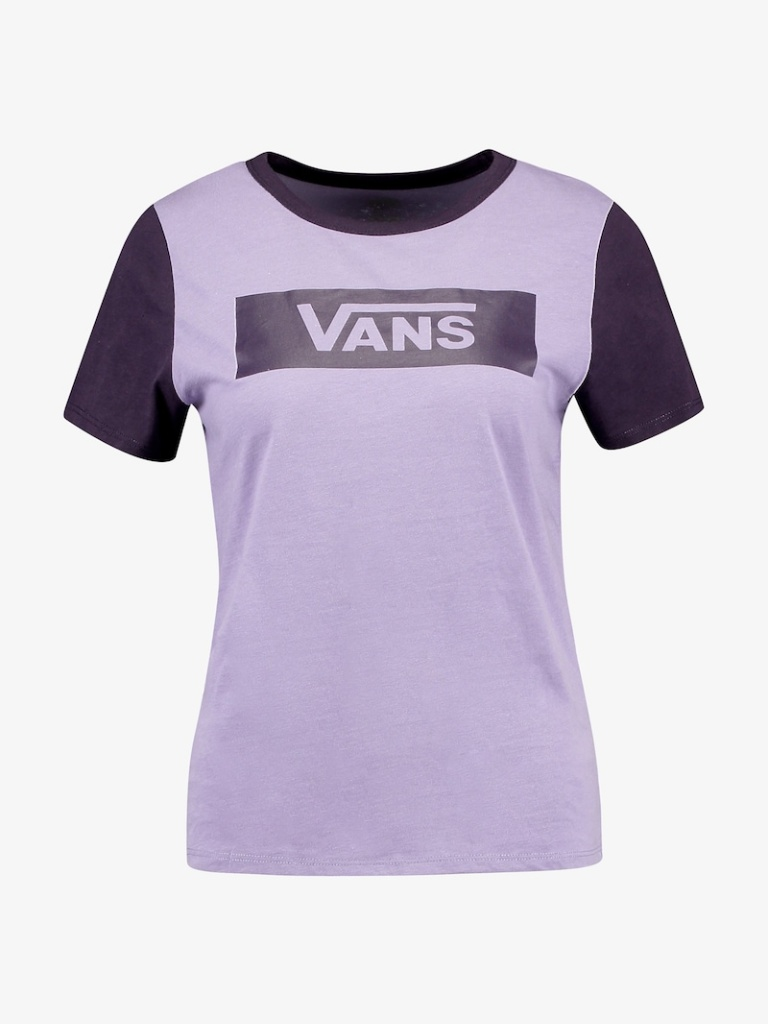

In [8]:
from PIL import Image

image_path = next(iter(uploaded))
image = Image.open(image_path).convert("RGB")

image

In [9]:
from transformers import AutoProcessor
from qwen_vl_utils import process_vision_info

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image,
            },
            {
                "type": "text",
                "text": """
Analyze the garment in the image and return ONLY valid JSON.

Use exactly this schema:

{
  "category": "",
  "primary_color": "",
  "secondary_color": "",
  "pattern": "",
  "material": "",
  "sleeve_type": "",
  "neckline": "",
  "fit": "",
  "gender": "",
  "season": "",
  "description": ""
}

Do not include markdown.
Do not explain your answer.
Return only JSON.
"""
            }
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
).to(model.device)

generated_ids = model.generate(
    **inputs,
    max_new_tokens=256,
)

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

output = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0]

print(output)

```json
{
  "category": "T-shirt",
  "primary_color": "lavender",
  "secondary_color": "black",
  "pattern": "solid",
  "material": "cotton",
  "sleeve_type": "short sleeve",
  "neckline": "round neck",
  "fit": "crop top",
  "gender": "female",
  "season": "summer",
  "description": "A lavender-colored crop top with black sleeves and a Vans logo on the chest."
}
```


In [11]:
print(repr(output))

'```json\n{\n  "category": "T-shirt",\n  "primary_color": "lavender",\n  "secondary_color": "black",\n  "pattern": "solid",\n  "material": "cotton",\n  "sleeve_type": "short sleeve",\n  "neckline": "round neck",\n  "fit": "crop top",\n  "gender": "female",\n  "season": "summer",\n  "description": "A lavender-colored crop top with black sleeves and a Vans logo on the chest."\n}\n```'


In [15]:
print("OUTPUT:")
print(repr(output))

clean_output = output.replace("`json", "").replace("```", "").strip()

print("\nCLEAN OUTPUT:")
print(repr(clean_output))

OUTPUT:
'```json\n{\n  "category": "T-shirt",\n  "primary_color": "lavender",\n  "secondary_color": "black",\n  "pattern": "solid",\n  "material": "cotton",\n  "sleeve_type": "short sleeve",\n  "neckline": "round neck",\n  "fit": "crop top",\n  "gender": "female",\n  "season": "summer",\n  "description": "A lavender-colored crop top with black sleeves and a Vans logo on the chest."\n}\n```'

CLEAN OUTPUT:
'``\n{\n  "category": "T-shirt",\n  "primary_color": "lavender",\n  "secondary_color": "black",\n  "pattern": "solid",\n  "material": "cotton",\n  "sleeve_type": "short sleeve",\n  "neckline": "round neck",\n  "fit": "crop top",\n  "gender": "female",\n  "season": "summer",\n  "description": "A lavender-colored crop top with black sleeves and a Vans logo on the chest."\n}'


In [17]:
print("output exists:", 'output' in globals())

if 'output' in globals():
    print("repr(output):")
    print(repr(output))
    print("Length:", len(output))

output exists: True
repr(output):
'```json\n{\n  "category": "T-shirt",\n  "primary_color": "lavender",\n  "secondary_color": "black",\n  "pattern": "solid",\n  "material": "cotton",\n  "sleeve_type": "short sleeve",\n  "neckline": "round neck",\n  "fit": "crop top",\n  "gender": "female",\n  "season": "summer",\n  "description": "A lavender-colored crop top with black sleeves and a Vans logo on the chest."\n}\n```'
Length: 369


In [18]:
import json

# Extract only the JSON between the first '{' and the last '}'
start = output.find("{")
end = output.rfind("}") + 1

clean_output = output[start:end]

print(clean_output)   # Verify it looks like JSON

result = json.loads(clean_output)

with open("q1_output.json", "w") as f:
    json.dump(result, f, indent=4)

print("✅ JSON saved successfully!")

{
  "category": "T-shirt",
  "primary_color": "lavender",
  "secondary_color": "black",
  "pattern": "solid",
  "material": "cotton",
  "sleeve_type": "short sleeve",
  "neckline": "round neck",
  "fit": "crop top",
  "gender": "female",
  "season": "summer",
  "description": "A lavender-colored crop top with black sleeves and a Vans logo on the chest."
}
✅ JSON saved successfully!
